In [356]:
import pandas as pd
import numpy as np
#import seaborn as sns
import matplotlib.pyplot as plt



## Main Task
- Write a function that takes in the uncertainty vector (i.e. a vector of the 9 proportions) and then computes total emissions
- The above function may be made up several subroutines/subfunctions that compute specific sectors (as you've already done below)
- Similarly, the function may return sector-specific emissions, as well, for future analysis
- Apply this function to samples_df (without using a loop) in order to compute the following columns: emissions, % change from baseline, and then columns for each of the sectors that change (those that do not change can be combined into something called "Other" (i.e. waste, agro, etc)
- Save the dataframe as `results/futures-ensemble.csv`

In [357]:
samples_df = pd.read_csv("../../results/lhs-samples.csv")
emissions = pd.read_excel('../../data/tidy/Emissions-Reduction-Calculation.xlsx')
activity = pd.read_csv('../../results/sectors/NewHaven-Emissions-Summary.csv')

# Remove rows starting from index 20
emissions = emissions.iloc[:20]

# Keep only the first four columns
emissions = emissions.iloc[:17, :4]
emissions

,Sector,Subsector,Year,Total Emissions (MMTCO2e)
0,Mobile Combustion,Automobile,2021.0,1.028899
1,Mobile Combustion,Motorcycle,2021.0,0.036643
2,Mobile Combustion,Trucks,2021.0,1.789613
3,Mobile Combustion,Buses,2021.0,0.020234
4,Electricity Consumption,Residential Electricity,2021.0,0.612048
5,Electricity Consumption,Commercial&Industrial Electricity,2021.0,0.702893
6,Solid Waste Landfills,Landfill fuel combustion,2021.0,0.000000
7,Solid Waste Landfills,Landfill methane,2021.0,0.000000
8,Stationary Combustion,Residential fuel oil,2020.0,0.760000
9,Stationary Combustion,Residential natural gas,2020.0,0.540000


In [358]:
E_motorcycle = emissions['Total Emissions (MMTCO2e)'][1]
E_buses = emissions['Total Emissions (MMTCO2e)'][3]

E_commr = emissions['Total Emissions (MMTCO2e)'][11]
E_indus = emissions['Total Emissions (MMTCO2e)'][12]
E_organic = emissions['Total Emissions (MMTCO2e)'][13]
E_synthetic = emissions['Total Emissions (MMTCO2e)'][14]
E_manure = emissions['Total Emissions (MMTCO2e)'][15]
E_waste = emissions['Total Emissions (MMTCO2e)'][16]

sum_emissions = emissions["Total Emissions (MMTCO2e)"].sum()
E_buses_motorcycle = E_motorcycle+E_buses
E_rest = E_commr+E_indus+E_organic+E_synthetic+E_manure+E_waste  

In [359]:
data = {
    'Label': ['u_1', 'u_2', 'u_3', 'u_4', 'u_5', 'u_6', 'u_7', 'u_8', 'u_9'],
    'Parameter': ['Car VMT', 'Truck VMT', 'Car MPG', 'E-grid Emissions Factor', 'Residential Electricity', 'Commercial/Industrial Electricity', 'Residential Fuel Oil', 'Residential Propane', 'Residential Natural Gas'],
    'Baseline Activity Value': [2.81, 3.87, 24.1, 543.85, 2.48, 2.85, 74.62, 9.98, 9988.5]
}
df = pd.DataFrame(data)

In [360]:
def total_emissions(activity_baseline, activity_change_df, emissions_factors):
    # Ensure the column names in `activity_change_df` match the `Parameter` column in `df`
    assert all(param in activity_change_df.columns for param in activity_baseline['Parameter']), "Column names in activity_change_df don't match Parameter names in df"

    # Now multiply the uncertainty values by their corresponding baseline activity values
    for param in activity_baseline['Parameter']:
        # Get the baseline value for the current parameter
        baseline_value = activity_baseline[activity_baseline['Parameter'] == param]['Baseline Activity Value'].values[0]

        # Multiply the values in activity_change_df[param] by the baseline value
        activity_change_df[param] = (1 + activity_change_df[param]) * baseline_value

    adjusted_activity = activity_change_df

    # Define emission models
    def model_emissions_Em(VMT, mpg, EFmco2, EFmch4, EFmn2o):
        return (VMT * 1e6 * EFmco2 / mpg + VMT * (EFmch4 + EFmn2o) * 1e3 * 25) / 1e6

    def model_emissions_Ee(Qe, EFe, divisor=2204.62):
        return Qe * EFe / divisor

    def model_emissions_Er(Qr, EFr):
        return Qr * EFr / 1e6  # Ensure you are dividing by 1e6

    # Calculate emissions
    emissions = {
        'mobile_car_vmt': model_emissions_Em(adjusted_activity['Car VMT'].to_numpy(), adjusted_activity['Car MPG'].to_numpy(),
                                             8.78, 0.008, 0.007),
        'mobile_trucks_vmt': model_emissions_Em(adjusted_activity['Truck VMT'].to_numpy(), 22.1,
                                                10.21, 0.001, 0.001),
        'mobile_buses_motorcycle': 0.06,  # Assuming you have no values here
        'electricity_residential': model_emissions_Ee(adjusted_activity['Residential Electricity'].to_numpy(), adjusted_activity['E-grid Emissions Factor'].to_numpy()),
        'electricity_commercial_industrial': model_emissions_Ee(adjusted_activity['Commercial/Industrial Electricity'].to_numpy(), adjusted_activity['E-grid Emissions Factor'].to_numpy()),
        'residential_oil': model_emissions_Er(adjusted_activity['Residential Fuel Oil'].to_numpy(), 10150 + 0.41 * 25 + 0.08 * 298),
        'residential_propane': model_emissions_Er(adjusted_activity['Residential Propane'].to_numpy(), 5720 + 0.27 * 25 + 0.05 * 298),
        'residential_gas': model_emissions_Er(adjusted_activity['Residential Natural Gas'].to_numpy(), 54.44),
        'rest': 1.42  # Placeholder for remaining emissions if needed
    }

    emissions_summary = pd.DataFrame(emissions)
    # Sum emissions across the rows (axis=0)
    emissions_summary_total = emissions_summary.sum(axis=1)
    emissions_percent = (6.97 - emissions_summary_total) / 6.97 * 100

#     # Create DataFrame for emissions summary
#     emissions_df = pd.DataFrame(emissions_summary_total, columns=['Emissions'])
    activity_change_df['Total_Emissions (MMTCO$_2$e)'] = emissions_summary_total
    activity_change_df['Emissions_Percentage (%)'] = emissions_percent

    
    return activity_change_df

In [361]:
results=total_emissions(df, samples_df, emissions_factors_df)
results.to_csv('../../results/activity-emissions-summary.csv', index=False)
results

,Car VMT,Truck VMT,Car MPG,E-grid Emissions Factor,Residential Electricity,Commercial/Industrial Electricity,Residential Fuel Oil,Residential Propane,Residential Natural Gas,Total_Emissions (MMTCO$_2$e),Emissions_Percentage (%)
0,0.327497,0.121933,47.442566,524.241703,2.724009,3.989121,43.677760,7.486817,10264.490076,4.240004,39.167803
1,3.341163,0.493949,24.628055,65.046320,2.185668,3.029433,11.537440,4.129393,12173.388759,3.858412,44.642581
2,1.242303,1.573558,42.074655,662.951421,2.504559,3.179567,43.297005,12.291576,14349.778674,5.468744,21.538820
3,0.514215,3.227973,57.485671,495.440979,1.380872,2.988359,103.799735,3.276230,12681.115720,5.798354,16.809841
4,0.697286,2.003201,27.417750,678.425426,3.466684,2.646914,49.465222,4.433646,244.470146,5.052969,27.504030
...,...,...,...,...,...,...,...,...,...,...,...
9995,0.751278,2.321671,58.094686,622.736804,2.581156,2.608066,108.716321,4.110105,8065.715007,5.702199,18.189396
9996,2.687831,3.581215,56.218452,84.866246,2.652532,4.037141,85.540997,4.700493,4279.989040,4.944117,29.065747
9997,1.119717,0.643587,43.513974,300.142181,2.100732,2.459675,24.721090,14.738590,2181.837580,3.079743,55.814302
9998,2.690807,2.804969,34.801331,467.329500,2.667358,3.152281,101.162414,9.109597,13187.327780,6.489982,6.886912


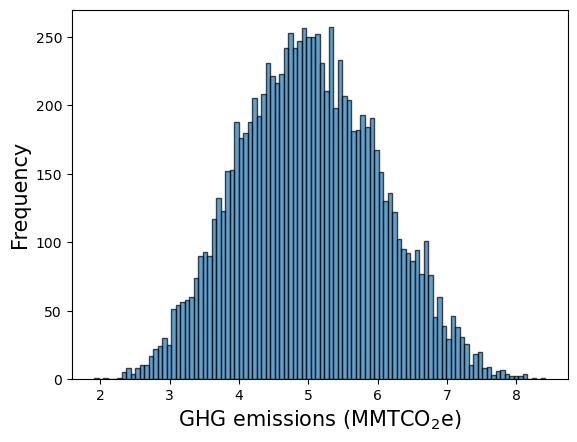

In [362]:
Etotal=results.iloc[:,9]
plt.hist(Etotal, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel("GHG emissions (MMTCO$_2$e)", fontsize=15)  # Adding x-axis title
plt.ylabel("Frequency", fontsize=15)  # Optional: Adding y-axis title for clarity
plt.savefig('../../figures/emissions-histogram.png', dpi=600, bbox_inches='tight')

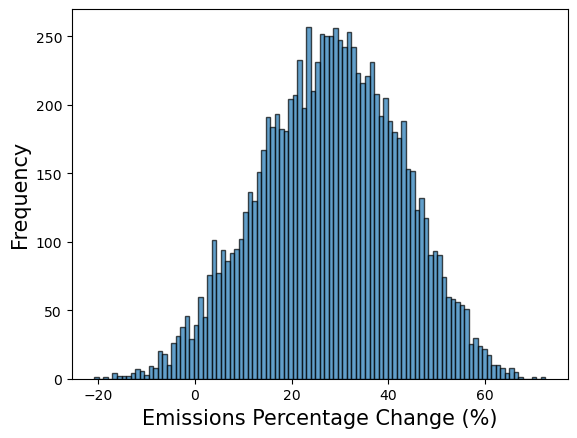

In [363]:
Epercent=results.iloc[:,10]

plt.hist(Epercent, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel("Emissions Percentage Change (%)", fontsize=15)  # Adding x-axis title
plt.ylabel("Frequency", fontsize=15)  # Optional: Adding y-axis title for clarity
plt.savefig('../../figures/emissions-percentage-change.png', dpi=600, bbox_inches='tight')